In [2]:
# All imports go here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pprint import pprint
from typing import Optional

In [37]:
# All useful constants go here
TRAIN_FILE = 'dataset/train.csv'
TEST_FILE = 'dataset/test.csv'

TRAIN_SAMPLES = None
TEST_SAMPLES = 10000

In [4]:
def read_bonus_malus(val: str, m_value: int = -1) -> Optional[int]:
    val_str = val.strip().upper()
    if val_str == 'M':
        return m_value
    try:
        return int(float(val_str))
    except:
        return None

def read_car_year(val: str, first_year=1900, last_year=2026) -> Optional[int]:
    val_str = val.replace('\xa0', '').strip()
    try:
        val_int = int(float(val_str))
        if val_int < first_year or val_int > last_year:
            return None
        return val_int
    except:
        return None

In [5]:
def load_dataset(path, nrows = None):
    df = pd.read_csv(path, nrows=nrows, 
                     converters={'bonus_malus': read_bonus_malus, 'car_year': read_car_year})
    
    # Pandas already have unique index
    assert df['unique_id'].nunique() == df.shape[0], f"{df['unique_id'].nunique()} != {df.shape[0]}"
    df.drop(columns="unique_id", inplace=True)

    # If no driver IIN just drop ???
    # We can also assume that this is new driver 
    df.dropna(subset=['driver_iin'], inplace=True)

    # Some numericals, that we can fill with zeros (probably)
    df.fillna({
        'claim_cnt': 0,
        'claim_amount': 0,
        'ownerkato_short': 0,
        'car_year': 0,
        'engine_volume': 0,
        'engine_power': 0,
    }, inplace=True)
    
    return df

In [6]:
def remove_scores(df: pd.DataFrame) -> pd.DataFrame:
    score_cols_mask = df.columns.str.startswith('SCORE')
    return df.loc[:,~score_cols_mask]

In [7]:
def prepare_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Assume short KATO is enough (or drop short instead)
    df.drop(columns=['ownerkato'], inplace=True)

    # Drop name columns
    df.drop(columns=[
        'is_individual_person_name', 
        'is_residence_name', 
        'region_name', 
        'age_experience_name', 
        'vehicle_type_name'
    ], inplace=True)
    
    # Drop model of car (or drop mark instead)
    df.drop(columns=['model'], inplace=True)

    # New features
    # How many percent of premium we actually get
    df['term'] = (df['premium_wo_term'] / df['premium']) * 100

    return df

In [8]:
def check_dataset(df: pd.DataFrame, train=True):
    count_df = df.groupby(['contract_number', 'driver_iin', 'car_number']).size().reset_index().rename(columns={0:'count'})
    non_unique = count_df[count_df['count'] > 1]
    assert non_unique.size == 0, f"(policy, driver, car) is unique for each row"

    if train:
        result = df.groupby('contract_number')['claim_cnt'].nunique() <= 1
        assert result.all(), "Claim count is unique for policy"
    
        result = df.groupby('contract_number')['is_claim'].nunique() <= 1
        assert result.all(), "isClaim is unique for policy"

    result = df.groupby(['contract_number', 'driver_iin'])['bonus_malus'].nunique() <= 1
    assert result.all(), "Bonus malus is unique for (policy, driver)"

In [9]:
# Loss Ratio Calculation (Коэффициент выплат)
def loss_ratio(df: pd.DataFrame) -> float:
    total_claims = df['claim_amount'].sum()
    total_premium = df['premium_wo_term'].sum()
    loss_ratio = (total_claims / total_premium) * 100 if total_premium != 0 else 0
    return loss_ratio

In [13]:
def just_increase(premium: float) -> float:
    return 3 * premium

In [38]:
# Load datasets
train_dfs = {}
test_dfs = {}

train_dfs['main'] = load_dataset(TRAIN_FILE, nrows=TRAIN_SAMPLES)
test_dfs['main'] = load_dataset(TEST_FILE, nrows=TEST_SAMPLES)

check_dataset(train_dfs['main'])
check_dataset(test_dfs['main'], train=False)

In [39]:
train_dfs['prepared'] = prepare_dataset(remove_scores(train_dfs['main']))
test_dfs['prepared'] = prepare_dataset(remove_scores(test_dfs['main']))

In [40]:
# Per policy table
train_dfs['policy'] = train_dfs['prepared'].groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
    'claim_amount': 'first',
    'claim_cnt': 'first',
    'is_claim': 'first',
    'term': 'first',
}).reset_index()

test_dfs['policy'] = test_dfs['main'].groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
}).reset_index()
mean_train_claim = train_dfs['policy']['claim_amount'].mean()
test_dfs['policy']['claim_amount'] = mean_train_claim

train_loss_ratio = loss_ratio(train_dfs['policy'])
test_loss_ratio = loss_ratio(test_dfs['policy'])
print(f"Train Loss Ratio: {train_loss_ratio:.2f}%")
print(f"Test Loss Ratio: {test_loss_ratio:.2f}%")
print(f"Mean train claim amount: {mean_train_claim:2f}")

Train Loss Ratio: 123.43%
Test Loss Ratio: 145.20%
Mean train claim amount: 13137.173331


In [41]:
train_after = train_dfs['policy'].copy()
k = train_loss_ratio / 70
train_after['premium'] = train_dfs['policy']['premium'].map(lambda p: k * p)
train_after['premium_wo_term'] = train_after['premium'] * (train_after['term'] / 100)

train_loss_ratio = loss_ratio(train_after)
print(f"Coefficient: {k:.2f}")
print(f"After Train Loss Ratio: {train_loss_ratio:.2f}%")

Coefficient: 1.76
After Train Loss Ratio: 70.00%


In [225]:
tp = train_dfs['prepared']
print(list(tp.columns))
tp.sort_values('claim_amount', ascending=False).head(10)

['contract_number', 'premium', 'premium_wo_term', 'operation_date', 'claim_amount', 'claim_cnt', 'is_claim', 'insurer_iin', 'driver_iin', 'is_individual_person', 'is_residence', 'region_id', 'bonus_malus', 'age_experience_id', 'experience_year', 'vehicle_type_id', 'car_age', 'ownerkato_short', 'mark', 'car_number', 'car_year', 'engine_volume', 'engine_power', 'term']


,contract_number,premium,premium_wo_term,operation_date,claim_amount,claim_cnt,is_claim,insurer_iin,driver_iin,is_individual_person,...,experience_year,vehicle_type_id,car_age,ownerkato_short,mark,car_number,car_year,engine_volume,engine_power,term
49408,e773f537f52e1c0a6a2b48e1d13b248b7b86a945558f76...,11351.0,11351.0,2022-02-01,6432300.0,1.0,1,425daebdba1bd362b26d62b23ca0e30c59a25bf9eb765b...,ec5af4dda2d70e9c7560d1a520d02f0e4aa5174d20a508...,1,...,0,1,свыше 7 лет,6146.0,LEXUS,8b16e629fe6f8ceb0ec268efc3172b660c010a37a51032...,2004.0,2995.0,82.0,100.0
28945,e773f537f52e1c0a6a2b48e1d13b248b7b86a945558f76...,11351.0,11351.0,2022-02-01,6432300.0,1.0,1,425daebdba1bd362b26d62b23ca0e30c59a25bf9eb765b...,425daebdba1bd362b26d62b23ca0e30c59a25bf9eb765b...,1,...,0,1,свыше 7 лет,6146.0,LEXUS,8b16e629fe6f8ceb0ec268efc3172b660c010a37a51032...,2004.0,2995.0,82.0,100.0
26091,c543abbf81af972ee85bf15e1dd01dd995b1406d5f2b94...,11431.0,11431.0,2022-02-01,6432300.0,1.0,1,3c0282c3ae506d22b98b6f12ad80451754cac847477544...,3c0282c3ae506d22b98b6f12ad80451754cac847477544...,1,...,8,1,свыше 7 лет,1968.0,MITSUBISHI,e612f227086e077ec24c704ce7380bf63181fa11631a20...,1991.0,2000.0,80.0,100.0
37261,1d7d12649ebc7971fd26f45099abe4ea84d4d834831bd6...,10135.0,10135.0,2022-02-01,3450000.0,1.0,1,28d43e8e7781409e8b0f0fe0b81ced48fbf81a23e01005...,b822de8a01035db5bbe052afc910fd07cd4b4209d6c007...,1,...,5,1,свыше 7 лет,6120.0,OPEL,3ac2d83bd72515688895e9c223bbcfabcaa7309575d90b...,1991.0,1796.0,66.0,100.0
4799,5fe3693f5a0696109d3b25a7bc2d18169aed89e50021b1...,10784.0,10784.0,2022-01-12,3450000.0,1.0,1,703bd56f2a836854b01b0ec172268ff2d2e6603bdb940c...,b4516c04905b2a8ea53eb36cbc4e232b55180212a3f12a...,1,...,3,1,свыше 7 лет,6152.0,DAEWOO,6d3d7941dfdf2551e1481a8e3b058705e3eb6e67c396eb...,2006.0,1500.0,55.0,100.0
4798,5fe3693f5a0696109d3b25a7bc2d18169aed89e50021b1...,10784.0,10784.0,2022-01-12,3450000.0,1.0,1,703bd56f2a836854b01b0ec172268ff2d2e6603bdb940c...,703bd56f2a836854b01b0ec172268ff2d2e6603bdb940c...,1,...,3,1,свыше 7 лет,6152.0,DAEWOO,6d3d7941dfdf2551e1481a8e3b058705e3eb6e67c396eb...,2006.0,1500.0,55.0,100.0
13963,48a542f5d8148f448d8d8c84766e964f88e5c094e2af2c...,13337.0,13337.0,2022-01-17,2540802.0,2.0,1,fe2a0b14fe821939b068b7250e999600eac96f6e31b6ba...,9887e79382475819f22e2ab6d7e78575b43841615cbc62...,1,...,5,1,свыше 7 лет,1952.0,MAZDA,be7422060f1a5e0e9c09811ef04c7f68f686bfd5a10ac0...,1990.0,1998.0,90.0,100.0
10499,48a542f5d8148f448d8d8c84766e964f88e5c094e2af2c...,13337.0,13337.0,2022-01-17,2540802.0,2.0,1,fe2a0b14fe821939b068b7250e999600eac96f6e31b6ba...,b1c7b021a7c07d1e8aff9401b3be08923a335cf9182f4b...,1,...,8,1,свыше 7 лет,1952.0,MAZDA,be7422060f1a5e0e9c09811ef04c7f68f686bfd5a10ac0...,1990.0,1998.0,90.0,100.0
8957,48a542f5d8148f448d8d8c84766e964f88e5c094e2af2c...,13337.0,13337.0,2022-01-17,2540802.0,2.0,1,fe2a0b14fe821939b068b7250e999600eac96f6e31b6ba...,fe2a0b14fe821939b068b7250e999600eac96f6e31b6ba...,1,...,3,1,свыше 7 лет,1952.0,MAZDA,be7422060f1a5e0e9c09811ef04c7f68f686bfd5a10ac0...,1990.0,1998.0,90.0,100.0
16195,48a542f5d8148f448d8d8c84766e964f88e5c094e2af2c...,13337.0,13337.0,2022-01-17,2540802.0,2.0,1,fe2a0b14fe821939b068b7250e999600eac96f6e31b6ba...,8a9accb52f7209b3911276a65f89c5d83419e7f2e20cab...,1,...,3,1,свыше 7 лет,1952.0,MAZDA,be7422060f1a5e0e9c09811ef04c7f68f686bfd5a10ac0...,1990.0,1998.0,90.0,100.0


In [265]:
df = train_dfs['main']
policy_car = df[["contract_number", "car_number", "mark", "claim_cnt"]].drop_duplicates()
cars_per_policy = policy_car.groupby("contract_number")["car_number"].nunique().reset_index(name="n_cars")
policy_car = policy_car.merge(cars_per_policy, on="contract_number")
policy_car["claim_share"] = (
    policy_car["claim_cnt"] / policy_car["n_cars"]
)
car_claims = (
    policy_car
    .groupby("car_number").agg({
        "mark": 'first',
        "claim_share": "sum",
        "n_cars": lambda _: 1,
    })
    .reset_index()
)

s = car_claims.groupby('mark')[["claim_share", "n_cars"]].sum()
s['crash_prob'] = (s['claim_share'] / s['n_cars']) * 100
s[s['n_cars'] > 10].sort_values('crash_prob', ascending=False)

,claim_share,n_cars,crash_prob
mark,,,
HYUNDAI,3.000000,12,25.000000
JAC,5.000000,48,10.416667
HOWO,1.000000,12,8.333333
CADILLAC,1.000000,13,7.692308
SUZUKI,4.000000,65,6.153846
LADA-21214,2.000000,33,6.060606
MAZDA,18.000000,418,4.306220
ЗИЛ,1.000000,24,4.166667
PEUGEOT,1.000000,27,3.703704


In [254]:
train_dfs['car'] = train_dfs['main'].groupby('car_number').agg({
    'mark': 'first',
    'model': 'first',
}).reset_index()

tc = train_dfs['car']
tc.shape

(21123, 3)

Text(0.5, 1.0, 'Claim vs No-Claim (Policy Count)')

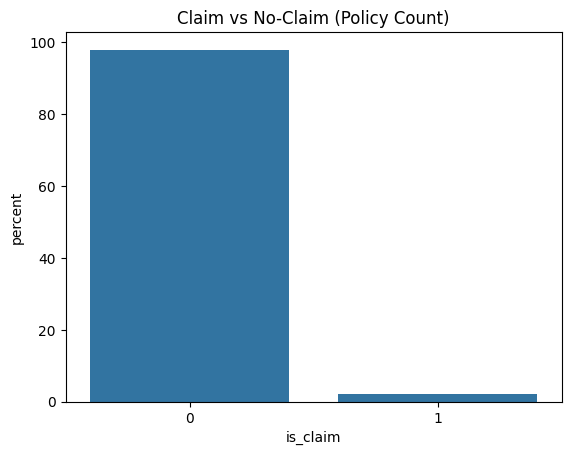

In [9]:
# Fancy plots go here

sns.countplot(x='is_claim', data=policy_df, stat='percent')
plt.title('Claim vs No-Claim (Policy Count)')

plt.figure(figsize=(57, 10))
train_df.groupby('car_year')['is_claim'].count().plot.bar()
plt.ylabel("Кол-во проишествий")
plt.xlabel("Год авто")

In [11]:
for column in train_df.columns:
    if column.endswith('_name'):
        print(column + ":")
        pprint(list(train_df[column].unique()))
        print()

is_individual_person_name:
['Физ. лицо']

is_residence_name:
['Резидент', 'Не резидент']

region_name:
['01 Алматинская область',
 '18 Туркестанская область',
 '14 Мангистауская область',
 '17 Шымкент',
 '12 Кызылординская область',
 '05 Карагандинская область',
 '15 Алматы',
 '09 Жамбылская область',
 '07 Акмолинская область',
 '16 Астана',
 '13 Атырауская область',
 '10 Актюбинская область',
 '03 Восточно-Казахстанская область',
 '04 Костанайская область',
 '08 Павлодарская область',
 '11 Западно-Казахстанская область',
 '06 Северо-Казахстанская область',
 'Временная регистрация',
 'Временный въезд']

age_experience_name:
['старше 25 лет/стаж вождения более 2 лет',
 'старше 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения более 2 лет']

vehicle_type_name:
['Легковые',
 'Прицепы(полуприцепы)',
 'Грузовые',
 'Мототранспорт',
 'Автобусы > 16 п.м.',
 'Автобусы до 16 п.м.']



In [15]:
total_claims = train_df.groupby('mark')['is_claim'].sum()
stats = pd.concat([train_df['mark'].value_counts(), total_claims], axis=1)
stats.columns = ['total_cars', 'total_accidents']
stats['accident_rate'] = stats['total_accidents'] / stats['total_cars']
stats

,total_cars,total_accidents,accident_rate
mark,,,
TOYOTA,19437,384,0.019756
HYUNDAI,7241,135,0.018644
VOLKSWAGEN,6412,129,0.020119
MERCEDES-BENZ,5149,59,0.011459
LADA,5077,102,0.020091
...,...,...,...
CF650-2,1,0,0.000000
CA1010A1,1,0,0.000000
ПЛ,1,0,0.000000


In [16]:
train_df['accident_rate_by_mark'] = train_df['mark'].map(stats['accident_rate'])
train_df[['accident_rate_by_mark']].head()

/tmp/ipykernel_28490/4213722452.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['accident_rate_by_mark'] = train_df['mark'].map(stats['accident_rate'])


,accident_rate_by_mark
0,0.018644
1,0.020091
2,0.014778
3,0.019756
4,0.018606
